In [ ]:
!unzip "/content/drive/MyDrive/fruits_classification.zip" -d "/content/"

Archive:  /content/drive/MyDrive/fruits_classification.zip
replace /content/fruits_classification/Fruit_dataset/classname.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
n

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'best_model.keras', 'drive', 'sample_data']


##Step 2: Data Collection

###Import Necessary Libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import(
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

###Dataset paths

In [ ]:
train_path = '/content/drive/MyDrive/ball_image_classification/train_data'
val_path = '/content/drive/MyDrive/ball_image_classification/val_data'
test_path = '/content/drive/MyDrive/ball_image_classification/test_data'

###Definition Of Image Parameters

In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

###Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
val_test_datagen =ImageDataGenerator(
    rescale = 1./255
)

###Load Images

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size= BATCH_SIZE,
    class_mode = 'categorical',
    shuffle=True
)

Found 150 images belonging to 6 classes.


In [ ]:
val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size= BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True
)

Found 29 images belonging to 6 classes.


In [ ]:
test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size = (IMG_HEIGHT,IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True
)

Found 30 images belonging to 6 classes.


###Check Class Names

In [ ]:
print(train_generator.class_indices)

{'Baseball': 0, 'Basketball': 1, 'Cricket': 2, 'Football': 3, 'Golf': 4, 'Volleyball': 5}


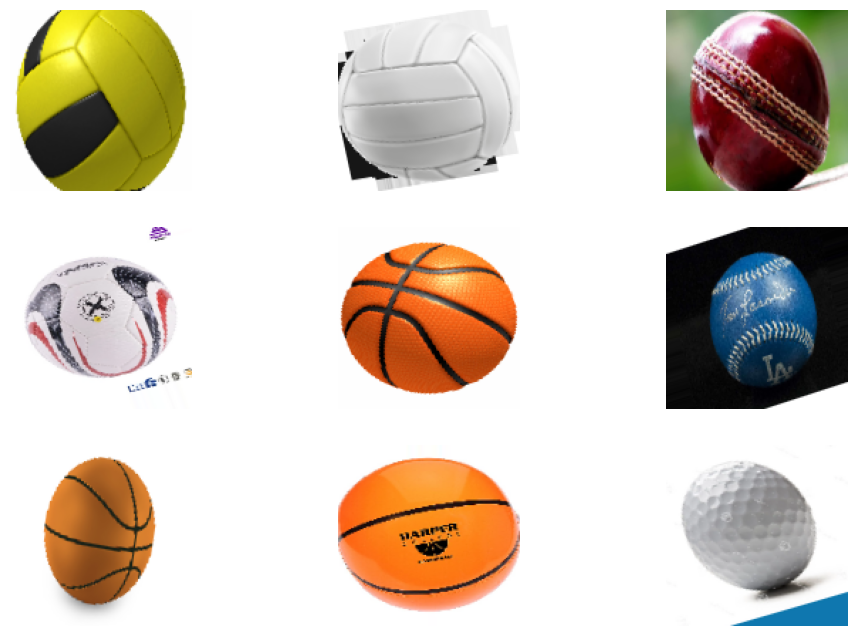

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()


##Model Building

In [ ]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# model.add(Conv2D(256,(3,3),activation='relu'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_generator.num_classes,activation='softmax'))


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,470 (24.87 MB)

 Trainable params: 6,518,022 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks = [early_stop,checkpoint]
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2733 - loss: 13.3586 - val_accuracy: 0.1724 - val_loss: 3.1574
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4533 - loss: 8.2879 - val_accuracy: 0.1724 - val_loss: 3.0575
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 775ms/step - accuracy: 0.5667 - loss: 4.6957 - val_accuracy: 0.1724 - val_loss: 3.1968
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6400 - loss: 3.5739 - val_accuracy: 0.2069 - val_loss: 5.6279
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7333 - loss: 2.3800 - val_accuracy: 0.1379 - val_loss: 5.0122
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7333 - loss: 2.3084 - val_accuracy: 0.2069 - val_loss: 7.8141
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7467 - loss: 1.4708 - val_accuracy: 0.2069 - val_loss: 16.9635


###Test Accuracy

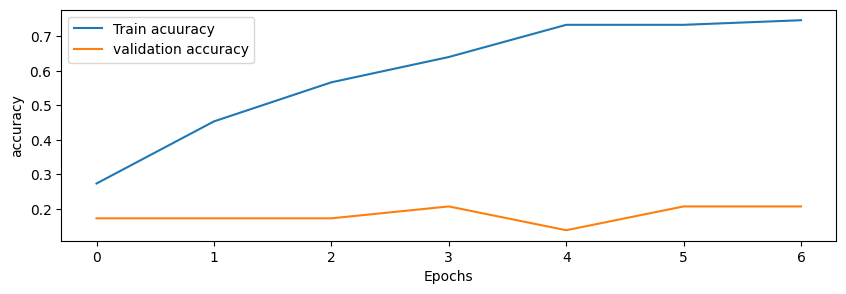

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(history.history['accuracy'],label='Train acuuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

###Train and validation Loss

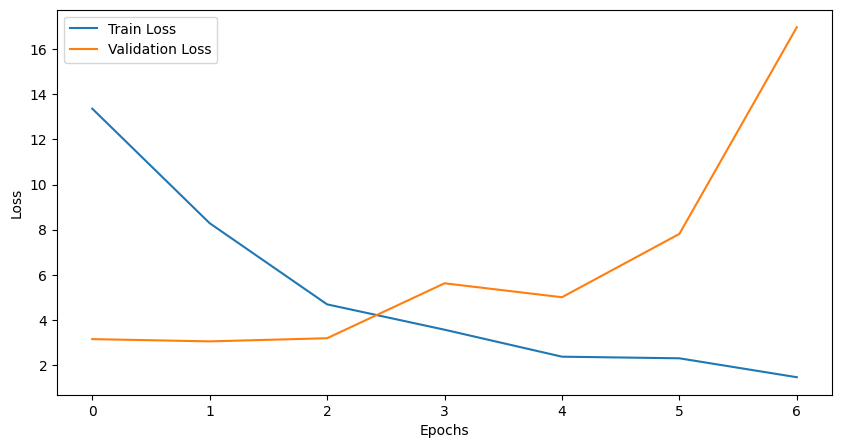

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
prediction = model.predict(test_generator)
predicted_classes = np.argmax(prediction,axis=1)
print('Predicted_class',predicted_classes)
true_classes = test_generator.classes
print(true_classes)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
Predicted_class [2 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]


###Test Evaluation

In [ ]:
test_loss,test_accuracy = model.evaluate(test_generator)
print('Test Loss:',test_loss)
print('Test Accuracy',test_accuracy)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 3.0446
Test Loss: 3.0445663928985596
Test Accuracy 0.1666666716337204


###Model Evaluation

In [ ]:
print(classification_report(
    true_classes,
    predicted_classes,
   target_names=list(test_generator.class_indices.keys())
))

              precision    recall  f1-score   support

    Baseball       0.00      0.00      0.00         5
  Basketball       0.00      0.00      0.00         5
     Cricket       0.00      0.00      0.00         5
    Football       0.00      0.00      0.00         5
        Golf       0.00      0.00      0.00         5
  Volleyball       0.17      1.00      0.29         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm = confusion_matrix(true_classes,predicted_classes)
print(cm)

[[0 0 1 0 0 4]
 [0 0 0 0 0 5]
 [0 0 0 0 0 5]
 [0 0 0 0 0 5]
 [0 0 0 0 0 5]
 [0 0 0 0 0 5]]


In [ ]:
model.save("cnn_image_classifier.h5")

In [ ]:
img_model = load_model('cnn_image_classifier.h5')

###Predict new image

In [ ]:
from tensorflow.keras.preprocessing import image
img_path ='/content/Screenshot 2026-07-20 150846.png'
img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array,axis=0)
prediction = img_model.predict(img_array)
predicted_index = np.argmax(prediction)
class_labels = dict((v,k) for k,v in train_generator.class_indices.items())

print("Predicted Class :", class_labels[predicted_index])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted Class : Volleyball


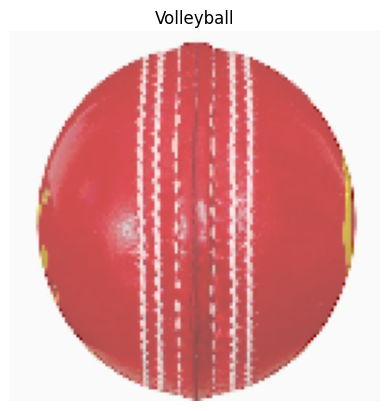

In [ ]:
plt.imshow(img)
plt.title(class_labels[predicted_index])
plt.axis("off")
plt.show()